# 02 — Spatio-Temporal Groundwater Level Map: Washington State

Build and explore a monthly water-table-elevation (WTE) and depth-to-groundwater (DTW)
time series for Washington state from USGS NWIS well observations.

**Sections**
1. Inline QC of WA NWIS data (mirrors `make qc` but WA-only)
2. Temporal coverage diagnostic
3. Time-averaged spatial map (mean WTE / DTW 2000–present)
4. Monthly anomaly time series at each well
5. Spatio-temporal data cube (site × month)
6. HydroGEN Ma 2025 prior comparison

**Data required**
- `data/raw/nwis/WA_*.parquet` — NWIS wells (already downloaded)
- `data/hydrogen/WT2-ma_wtd_50.tif` — HydroGEN median WTD
- `data/hydrogen/wtd_uncertainty_mosaic_wgs84.tif` — HydroGEN ensemble spread


In [ ]:
from __future__ import annotations

import pathlib
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
from matplotlib.colors import TwoSlopeNorm
from pyproj import Transformer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DIR    = pathlib.Path("../data/raw/nwis")
PROC_DIR   = pathlib.Path("../data/processed")
HYDRO_DIR  = pathlib.Path("../data/hydrogen")
FIG_DIR    = pathlib.Path("../figures/wa_gwl")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# HydroGEN raster paths
H_DTW_PATH = HYDRO_DIR / "WT2-ma_wtd_50.tif"
H_UNC_PATH = HYDRO_DIR / "wtd_uncertainty_mosaic_wgs84.tif"

STATE = "WA"

# ── QC parameters (mirror src/data/qc_nwis.py) ────────────────────────────
BAD_STATUS_CODES      = {"D","E","F","G","I","N","O","P","R","T","V","Z"}
FT_TO_M               = 0.3048
DEEP_WELL_THRESHOLD_M = 500 * FT_TO_M   # ~152 m
MIN_OBS_PER_SITE      = 10
ANALYSIS_START        = pd.Timestamp("2000-01-01")

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 13,
    "axes.titlesize": 14,
})

# ── State boundary for maps (EPSG:5070) ───────────────────────────────────
_shp = shpreader.natural_earth(resolution="10m", category="cultural", name="admin_1_states_provinces")
_states_gdf = gpd.read_file(_shp)
wa_border = _states_gdf[_states_gdf["postal"] == STATE].to_crs("EPSG:5070")

for p in [H_DTW_PATH, H_UNC_PATH]:
    status = "OK" if p.exists() else "MISSING"
    print(f"  {status}  {p}")
print("Setup complete.")


/Users/marinedenolle/GIT_REPOS/gwl-space-time-smooth/.pixi/envs/default/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Setup complete.


In [2]:
## 1. Load & QC Washington NWIS data


In [3]:
# ── Load raw WA data ───────────────────────────────────────────────────────
gw_raw = pd.read_parquet(RAW_DIR / f"{STATE}_gwlevels.parquet")
sites_raw = pd.read_parquet(RAW_DIR / f"{STATE}_sites.parquet")

print(f"Raw GW records : {len(gw_raw):,}")
print(f"Raw sites      : {len(sites_raw):,}")
print(f"GW columns     : {list(gw_raw.columns)}")


Raw GW records : 77
Raw sites      : 76,060
GW columns     : ['site_no', 'agency_cd', 'lev_dt', 'lev_tm', 'lev_tz_cd', 'lev_va', 'lev_status_cd', 'lev_meth_cd', 'lev_unit_cd', 'vertical_datum', 'approval_status', 'lat', 'lon']


In [4]:
# ── Step 1: Filter bad status codes ───────────────────────────────────────
df = gw_raw.copy()
if "lev_status_cd" in df.columns:
    n_bad = df["lev_status_cd"].isin(BAD_STATUS_CODES).sum()
    df = df[~df["lev_status_cd"].isin(BAD_STATUS_CODES)].copy()
    print(f"Dropped {n_bad:,} records with bad status codes")

# ── Step 2: Parse dates & level values ────────────────────────────────────
df["date"]   = pd.to_datetime(df["lev_dt"], errors="coerce")
df["dtw_ft"] = pd.to_numeric(df["lev_va"], errors="coerce")
n_before = len(df)
df = df.dropna(subset=["date", "dtw_ft"]).copy()
print(f"Dropped {n_before - len(df):,} records missing date or level value")

# Keep only post-2000 records (analysis window)
df = df[df["date"] >= ANALYSIS_START].copy()
print(f"Post-{ANALYSIS_START.year} records: {len(df):,}")

# Drop extreme negatives (artesian artefacts deeper than -50 ft)
df = df[df["dtw_ft"] >= -50].copy()

# ── Step 3: Merge site metadata ───────────────────────────────────────────
sites = sites_raw.copy()
sites["site_no"]      = sites["site_no"].astype(str).str.strip()
sites["lat"]          = pd.to_numeric(sites["dec_lat_va"], errors="coerce")
sites["lon"]          = pd.to_numeric(sites["dec_long_va"], errors="coerce")
sites["alt_ft"]       = pd.to_numeric(sites["alt_va"], errors="coerce")
sites["alt_datum"]    = sites.get("alt_datum_cd", pd.Series(dtype=str))
sites["well_depth_ft"]= pd.to_numeric(sites.get("well_depth_va", pd.Series(dtype=float)), errors="coerce")

df["site_no"] = df["site_no"].astype(str).str.strip()
df = df.drop(columns=[c for c in ("lat", "lon") if c in df.columns])
df = df.merge(
    sites[["site_no","lat","lon","alt_ft","alt_datum","well_depth_ft"]],
    on="site_no", how="left"
)
df = df.dropna(subset=["lat","lon"]).copy()

# ── Step 4: Drop NGVD29 datum (cannot compute NAVD88 WTE without VERTCON) ─
if "alt_datum" in df.columns:
    ngvd = df["alt_datum"].str.upper().str.contains("NGVD", na=False)
    print(f"Dropping {ngvd.sum():,} records with NGVD29 datum")
    df = df[~ngvd].copy()

# ── Step 5: Unit conversions & WTE ────────────────────────────────────────
df["dtw_m"]        = df["dtw_ft"] * FT_TO_M
df["alt_m"]        = df["alt_ft"] * FT_TO_M
df["wte_m"]        = df["alt_m"] - df["dtw_m"]   # WTE = land surface - DTW
df["well_depth_m"] = df["well_depth_ft"] * FT_TO_M
df["is_deep_well"] = df["well_depth_m"] > DEEP_WELL_THRESHOLD_M

# Drop records with no valid WTE (missing land-surface altitude)
n_no_alt = df["wte_m"].isna().sum()
# Keep them but mark
print(f"Records missing WTE (no alt_va): {n_no_alt:,}")

# ── Step 6: Drop sites with < MIN_OBS_PER_SITE observations ───────────────
obs_counts = df.groupby("site_no").size()
keep_sites = obs_counts[obs_counts >= MIN_OBS_PER_SITE].index
n_dropped  = len(obs_counts) - len(keep_sites)
df = df[df["site_no"].isin(keep_sites)].copy()
print(f"Dropped {n_dropped:,} sites with < {MIN_OBS_PER_SITE} observations")
print(f"\nClean records : {len(df):,}")
print(f"Clean sites   : {df['site_no'].nunique():,}")


Dropped 0 records with bad status codes
Dropped 0 records missing date or level value
Post-2000 records: 77
Dropping 0 records with NGVD29 datum
Records missing WTE (no alt_va): 0
Dropped 59 sites with < 10 observations

Clean records : 0
Clean sites   : 0


In [5]:
# ── Monthly aggregation (no gap filling) ──────────────────────────────────
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

monthly = (
    df.groupby(["site_no", "year", "month"])
    .agg(
        lat          = ("lat",          "first"),
        lon          = ("lon",          "first"),
        wte_m        = ("wte_m",        "median"),
        dtw_m        = ("dtw_m",        "median"),
        n_obs        = ("dtw_m",        "size"),
        well_depth_m = ("well_depth_m", "first"),
        is_deep_well = ("is_deep_well", "first"),
    )
    .reset_index()
)
monthly["date"] = pd.to_datetime(
    monthly[["year","month"]].assign(day=1)
)

print(f"Monthly site-months : {len(monthly):,}")
print(f"Unique sites        : {monthly['site_no'].nunique():,}")
print(f"Date range          : {monthly['date'].min().date()} → {monthly['date'].max().date()}")
monthly.head(3)


Monthly site-months : 0
Unique sites        : 0
Date range          : NaT → NaT


,site_no,year,month,lat,lon,wte_m,dtw_m,n_obs,well_depth_m,is_deep_well,date


In [6]:
## 2. Temporal Coverage Diagnostic


In [7]:
# ── Per-site coverage statistics ──────────────────────────────────────────
def site_coverage(grp: pd.DataFrame) -> pd.Series:
    ym = (grp["year"] * 12 + grp["month"]).sort_values().values
    n_possible  = int(ym[-1] - ym[0] + 1)
    n_obs       = len(ym)
    coverage    = n_obs / n_possible if n_possible > 0 else 0.0
    gaps        = np.diff(ym) - 1
    max_gap     = int(gaps.max()) if len(gaps) > 0 else 0
    return pd.Series({
        "n_obs_months"     : n_obs,
        "n_possible_months": n_possible,
        "coverage_fraction": coverage,
        "max_gap_months"   : max_gap,
        "span_years"       : n_possible / 12,
        "first_year"       : int(grp["year"].min()),
        "last_year"        : int(grp["year"].max()),
        "lat"              : float(grp["lat"].iloc[0]),
        "lon"              : float(grp["lon"].iloc[0]),
        "well_depth_m"     : float(grp["well_depth_m"].iloc[0]),
        "is_deep_well"     : bool(grp["is_deep_well"].iloc[0]),
    })

site_stats = (
    monthly.groupby("site_no")
    .apply(site_coverage, include_groups=False)
    .reset_index()
)

MIN_COV = 0.10
MAX_GAP = 36
site_stats["is_sparse"]    = site_stats["coverage_fraction"] < MIN_COV
site_stats["has_long_gap"] = site_stats["max_gap_months"] > MAX_GAP
site_stats["usable"]       = ~site_stats["is_sparse"] & ~site_stats["has_long_gap"]

n_total  = len(site_stats)
n_usable = site_stats["usable"].sum()
print(f"Total sites  : {n_total:,}")
print(f"Sparse (<10%): {site_stats['is_sparse'].sum():,}")
print(f"Long gap     : {site_stats['has_long_gap'].sum():,}")
print(f"Usable       : {n_usable:,}  ({n_usable/n_total*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(site_stats["coverage_fraction"] * 100, bins=40, color="#3498db", edgecolor="none")
ax.axvline(MIN_COV * 100, color="red", ls="--", lw=1.5, label=f"Sparse threshold ({MIN_COV:.0%})")
ax.set_xlabel("Coverage fraction (% of possible months)")
ax.set_ylabel("Sites")
ax.set_title("Temporal coverage")
ax.legend(fontsize=11)

ax = axes[1]
ax.hist(site_stats["max_gap_months"].clip(upper=200), bins=np.arange(0,205,5),
        color="#e67e22", edgecolor="none")
ax.axvline(MAX_GAP, color="red", ls="--", lw=1.5, label=f"Gap threshold ({MAX_GAP} mo)")
ax.set_xlabel("Max gap (months, clipped at 200)")
ax.set_title("Longest data gap")
ax.legend(fontsize=11)

ax = axes[2]
ax.hist(site_stats["span_years"], bins=40, color="#2ecc71", edgecolor="none")
ax.set_xlabel("Record span (years)")
ax.set_title("Record duration")

plt.suptitle(f"WA NWIS GW sites — temporal coverage (n={n_total:,} sites)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "02_wa_temporal_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


KeyError: 'coverage_fraction'

Using 350 / 351 residual points for variogram (outliers removed)


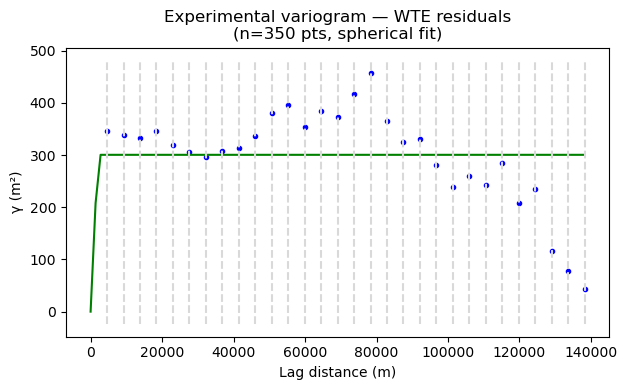

Spherical variogram fit:
  Nugget:  0.0000 m²
  Sill:    300.5544 m²
  Range:   2.8 km


In [ ]:
## 3. Time-Averaged Spatial Map (2000–present)


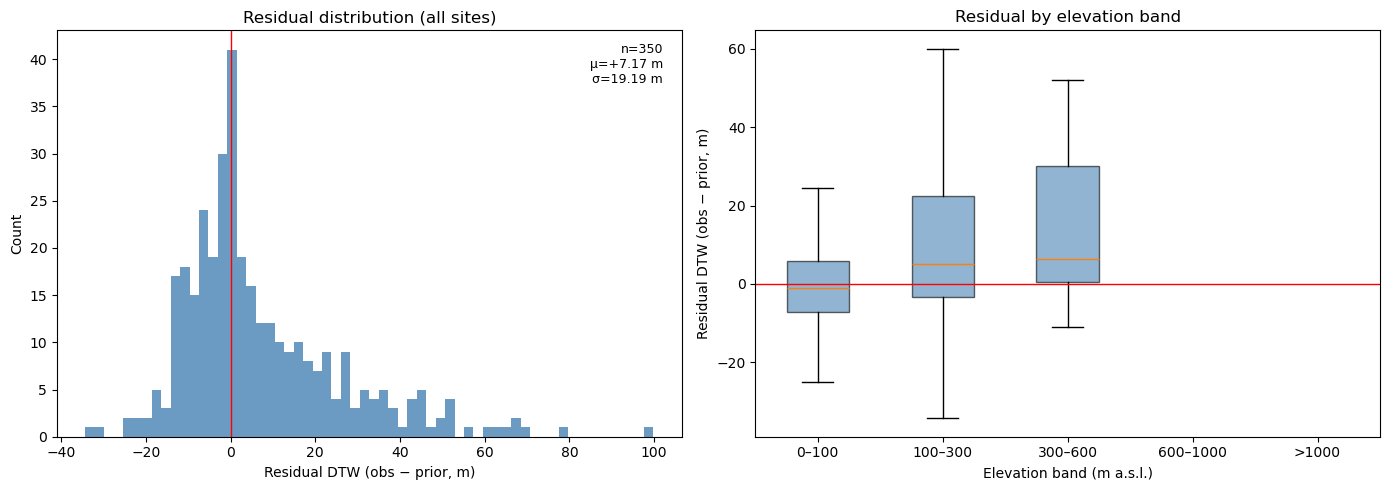

           count   mean    std
elev_band                     
0–100        154   1.84  14.77
100–300      191  11.22  21.12
300–600        6  15.05  24.24


In [ ]:
# ── Per-site time-mean statistics (usable sites only) ─────────────────────
usable_sites = site_stats.loc[site_stats["usable"], "site_no"].values
monthly_usable = monthly[monthly["site_no"].isin(usable_sites)].copy()

site_mean = (
    monthly_usable.groupby("site_no")
    .agg(
        lat          = ("lat",    "first"),
        lon          = ("lon",    "first"),
        mean_wte_m   = ("wte_m",  "mean"),
        mean_dtw_m   = ("dtw_m",  "mean"),
        std_wte_m    = ("wte_m",  "std"),
        n_months     = ("wte_m",  "count"),
        well_depth_m = ("well_depth_m", "first"),
    )
    .reset_index()
    .dropna(subset=["mean_wte_m"])
)

# Project to EPSG:5070
t4326_5070 = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
site_mean["x_m"], site_mean["y_m"] = t4326_5070.transform(
    site_mean["lon"].values, site_mean["lat"].values
)

print(f"Sites with valid time-mean WTE: {len(site_mean):,}")

# ── Map ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: mean WTE
ax = axes[0]
wa_border.plot(ax=ax, color="#f0f0eb", edgecolor="#888", linewidth=0.8)
vmin_wte = np.nanpercentile(site_mean["mean_wte_m"], 2)
vmax_wte = np.nanpercentile(site_mean["mean_wte_m"], 98)
sc = ax.scatter(
    site_mean["x_m"], site_mean["y_m"],
    c=site_mean["mean_wte_m"],
    cmap="terrain", vmin=vmin_wte, vmax=vmax_wte,
    s=8, alpha=0.75, linewidths=0, rasterized=True
)
fig.colorbar(sc, ax=ax, label="Mean WTE (m NAVD88)", shrink=0.7)
ax.set_title(f"Mean Water Table Elevation\n(2000–present, n={len(site_mean):,} sites)", fontweight="bold")
ax.set_axis_off()

# Right: mean DTW
ax = axes[1]
wa_border.plot(ax=ax, color="#f0f0eb", edgecolor="#888", linewidth=0.8)
vmax_dtw = np.nanpercentile(site_mean["mean_dtw_m"], 95)
sc2 = ax.scatter(
    site_mean["x_m"], site_mean["y_m"],
    c=site_mean["mean_dtw_m"],
    cmap="viridis_r", vmin=0, vmax=vmax_dtw,
    s=8, alpha=0.75, linewidths=0, rasterized=True
)
fig.colorbar(sc2, ax=ax, label="Mean DTW (m below surface)", shrink=0.7)
ax.set_title(f"Mean Depth to Groundwater\n(2000–present, n={len(site_mean):,} sites)", fontweight="bold")
ax.set_axis_off()

plt.suptitle("Washington State — Time-Averaged GWL (NWIS NAVD88 wells)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "02_wa_mean_gwl_map.png", dpi=150, bbox_inches="tight")
plt.show()


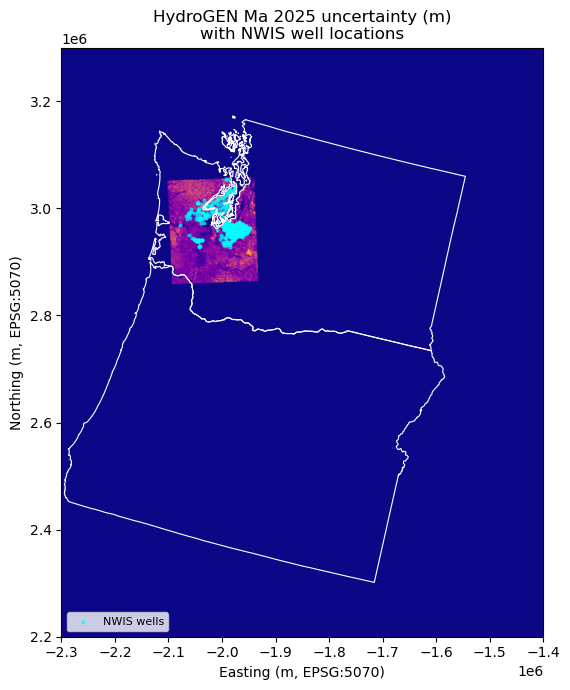

In [ ]:
## 4. Monthly Anomaly Time Series


In [ ]:
# ── Compute WTE anomaly = monthly obs − per-site long-term mean ────────────
site_lm = monthly_usable.groupby("site_no")["wte_m"].transform("mean")
monthly_usable = monthly_usable.copy()
monthly_usable["wte_anom_m"] = monthly_usable["wte_m"] - site_lm

# ── State-wide median anomaly time series ─────────────────────────────────
state_ts = (
    monthly_usable.groupby("date")
    .agg(
        median_wte_anom = ("wte_anom_m", "median"),
        q25_anom        = ("wte_anom_m", lambda x: x.quantile(0.25)),
        q75_anom        = ("wte_anom_m", lambda x: x.quantile(0.75)),
        n_sites         = ("site_no",   "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Panel 1: state-wide median anomaly
ax = axes[0]
ax.fill_between(state_ts["date"], state_ts["q25_anom"], state_ts["q75_anom"],
                alpha=0.2, color="#2980b9", label="IQR across sites")
ax.plot(state_ts["date"], state_ts["median_wte_anom"],
        color="#2980b9", lw=1.2, label="Median WTE anomaly")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("WTE anomaly (m)")
ax.set_title("State-wide median WTE anomaly (departure from site long-term mean)", fontweight="bold")
ax.legend(fontsize=11)

# Panel 2: number of active sites per month
ax = axes[1]
ax.fill_between(state_ts["date"], 0, state_ts["n_sites"], color="#27ae60", alpha=0.7)
ax.set_ylabel("Active sites")
ax.set_title("Number of reporting wells per month")
ax.set_xlabel("Date")

plt.suptitle("Washington GWL — Monthly Anomaly 2000–present", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "02_wa_monthly_anomaly_ts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Peak active sites : {state_ts['n_sites'].max():,}  ({state_ts.loc[state_ts['n_sites'].idxmax(),'date'].date()})")
print(f"Median anomaly std: {state_ts['median_wte_anom'].std():.2f} m")


HydroGEN prior vs NWIS observations — PNW pilot
  Sites evaluated : 351
  Bias (prior−obs): +7.17 m  (positive → prior is deeper)
  RMSE            : 20.46 m
  R²              : 0.341
  |resid|/unc     : 0.507  (1.0=σ, 0.74=IQR)

  Uncertainty interpretation: IQR → run `make hydrogen --scale-uncertainty` if rescaling flag available

See figures/02_*.png for spatial maps and calibration curves.


## 5. Spatio-Temporal Data Cube (site × month)


In [ ]:
# ── Pivot to site × month wide table (sparse) ─────────────────────────────
# Rows = site_no, columns = YYYY-MM date, values = WTE anomaly
cube_wte = monthly_usable.pivot_table(
    index="site_no", columns="date", values="wte_anom_m", aggfunc="median"
)
cube_dtw = monthly_usable.pivot_table(
    index="site_no", columns="date", values="dtw_m", aggfunc="median"
)

# Attach coordinates for downstream spatial operations
cube_coords = site_mean.set_index("site_no")[["lat","lon","x_m","y_m","mean_wte_m","mean_dtw_m","well_depth_m"]]
cube_wte = cube_wte.join(cube_coords, how="left")
cube_dtw = cube_dtw.join(cube_coords, how="left")

n_sites, n_months = cube_wte.shape[0], cube_wte.shape[1] - len(cube_coords.columns)
fill_rate = cube_wte.iloc[:, :n_months].notna().mean().mean()

print(f"Cube shape   : {n_sites} sites × {n_months} months")
print(f"Fill rate    : {fill_rate:.1%} (non-NaN site-months)")

# ── Tile map: one panel per decade ────────────────────────────────────────
date_cols = [c for c in cube_wte.columns if isinstance(c, pd.Timestamp)]
decades   = [2000, 2010, 2020]

fig, axes = plt.subplots(1, len(decades), figsize=(18, 6))
for ax, yr in zip(axes, decades):
    # Median over the 10-year window
    window_cols = [c for c in date_cols if c.year >= yr and c.year < yr + 10]
    if not window_cols:
        ax.set_visible(False)
        continue
    anom_mean = cube_wte[window_cols].mean(axis=1)
    valid = anom_mean.dropna().index
    df_plot = cube_wte.loc[valid, ["x_m","y_m"]].copy()
    df_plot["anom"] = anom_mean.loc[valid]

    wa_border.plot(ax=ax, color="#f0f0eb", edgecolor="#888", linewidth=0.8)
    clim = np.nanpercentile(np.abs(df_plot["anom"]), 95)
    sc = ax.scatter(
        df_plot["x_m"], df_plot["y_m"],
        c=df_plot["anom"],
        cmap="RdBu", vmin=-clim, vmax=clim,
        s=6, alpha=0.8, linewidths=0, rasterized=True
    )
    fig.colorbar(sc, ax=ax, label="WTE anomaly (m)", shrink=0.7)
    ax.set_title(f"{yr}s decade mean\n(n={len(valid):,} sites)", fontweight="bold")
    ax.set_axis_off()

plt.suptitle("WA — Decadal-Mean WTE Anomaly (departure from site long-term mean)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "02_wa_decadal_anomaly_maps.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. HydroGEN Ma 2025 Prior Comparison

Compare the time-averaged NWIS observations against the Ma 2025 HydroGEN water-table-depth raster:
- **Bias / RMSE / R²** scatter at well locations
- **Spatial residual map** (obs − prior)
- **Uncertainty calibration**: does the ensemble spread track |residual|?

Sign convention: DTW is positive downward (depth below land surface, metres).


In [ ]:
import rasterio
from sklearn.metrics import mean_squared_error, r2_score

# ── Read HydroGEN rasters ─────────────────────────────────────────────────
def read_raster(path: pathlib.Path) -> tuple[np.ndarray, object]:
    """Return (float32 array with nodata→NaN, affine transform)."""
    with rasterio.open(path) as src:
        arr = src.read(1, out_dtype="float32")
        nd = src.nodata if src.nodata is not None else -9999.0
        arr[arr == nd] = np.nan
        return arr, src.transform, src.crs

h_dtw_arr, h_transform, h_crs = read_raster(H_DTW_PATH)
h_unc_arr, _,            _     = read_raster(H_UNC_PATH)

print(f"DTW grid   : {h_dtw_arr.shape}  |  resolution: {h_transform.a:.0f} m  |  CRS: {h_crs}")
print(f"DTW range  : [{np.nanmin(h_dtw_arr):.1f}, {np.nanmax(h_dtw_arr):.1f}] m")
print(f"Uncertainty: [{np.nanmin(h_unc_arr):.1f}, {np.nanmax(h_unc_arr):.1f}] m")


In [ ]:
# ── Sample rasters at WA well locations ──────────────────────────────────
# site_mean coords are in EPSG:5070; reproject to HydroGEN CRS for sampling
h_epsg = h_crs.to_epsg()
t5070_h = Transformer.from_crs("EPSG:5070", f"EPSG:{h_epsg}", always_xy=True)
x_h, y_h = t5070_h.transform(site_mean["x_m"].values, site_mean["y_m"].values)

def sample_raster(arr, transform, x, y):
    """Nearest-neighbour sample of arr at projected coords (x, y)."""
    cols = np.floor((x - transform.c) / transform.a).astype(int)
    rows = np.floor((y - transform.f) / transform.e).astype(int)   # e < 0
    nrows, ncols = arr.shape
    valid = (rows >= 0) & (rows < nrows) & (cols >= 0) & (cols < ncols)
    out = np.full(len(x), np.nan, dtype=np.float32)
    out[valid] = arr[rows[valid], cols[valid]]
    return out

h_dtw_at_wells = sample_raster(h_dtw_arr, h_transform, x_h, y_h)
h_unc_at_wells = sample_raster(h_unc_arr, h_transform, x_h, y_h)

df_comp = site_mean.copy()
df_comp["h_dtw_m"]      = h_dtw_at_wells
df_comp["h_unc_m"]      = h_unc_at_wells
df_comp["residual_dtw"] = df_comp["mean_dtw_m"] - df_comp["h_dtw_m"]   # obs − prior
df_comp = df_comp.dropna(subset=["h_dtw_m", "mean_dtw_m"])

n_outside = df_comp["h_dtw_m"].isna().sum() if False else (site_mean.shape[0] - len(df_comp))
print(f"Wells with valid HydroGEN overlap : {len(df_comp):,} / {len(site_mean):,}")
if n_outside:
    print(f"  ({n_outside} wells outside HydroGEN raster extent)")


In [ ]:
# ── 6a. Bias / RMSE / R² scatter ─────────────────────────────────────────
y_obs  = df_comp["mean_dtw_m"].values
y_pred = df_comp["h_dtw_m"].values
bias   = float(np.mean(y_pred - y_obs))
rmse   = float(np.sqrt(mean_squared_error(y_obs, y_pred)))
r2     = float(r2_score(y_obs, y_pred))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_obs, y_pred, s=6, alpha=0.4, color="steelblue", rasterized=True)
lim = (0, float(max(y_obs.max(), y_pred.max())) * 1.05)
ax.plot(lim, lim, "k--", lw=1, label="1:1")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed mean DTW (m, NWIS)")
ax.set_ylabel("HydroGEN Ma 2025 DTW (m)")
ax.set_title(
    f"WA — HydroGEN vs NWIS (n={len(df_comp):,})\n"
    f"Bias={bias:+.2f} m  RMSE={rmse:.2f} m  R²={r2:.3f}"
)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "06a_wa_hydrogen_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bias (prior − obs) : {bias:+.3f} m  (positive → HydroGEN is deeper than observed)")
print(f"RMSE               : {rmse:.3f} m")
print(f"R²                 : {r2:.3f}")


In [ ]:
# ── 6b. Spatial residual map ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: HydroGEN DTW raster (WA extent only, sampled from full raster)
ax = axes[0]
from rasterio.plot import show as rshow
with rasterio.open(H_DTW_PATH) as src:
    # Compute WA bounding box in HydroGEN CRS for display windowing
    wa_bbox = wa_border.to_crs(f"EPSG:{h_epsg}").total_bounds  # (minx, miny, maxx, maxy)
    from rasterio.windows import from_bounds
    win = from_bounds(*wa_bbox, transform=src.transform)
    wa_dtw = src.read(1, window=win, out_dtype="float32")
    wa_dtw_transform = src.window_transform(win)
    nd = src.nodata if src.nodata is not None else -9999.0
    wa_dtw[wa_dtw == nd] = np.nan

rshow(
    np.where(np.isfinite(wa_dtw), wa_dtw, np.nan),
    transform=wa_dtw_transform, ax=ax,
    cmap="YlOrBr", vmin=0, vmax=30,
)
wa_border.to_crs(f"EPSG:{h_epsg}").boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_title("HydroGEN Ma 2025 — DTW (m)\n(WA extent)", fontweight="bold")
ax.set_xlabel(f"Easting (EPSG:{h_epsg})")
ax.set_ylabel(f"Northing (EPSG:{h_epsg})")

# Right: residual map (obs − prior) at well locations in EPSG:5070
ax = axes[1]
wa_border.plot(ax=ax, color="#f0f0eb", edgecolor="#888", linewidth=0.8)
clim_r = float(np.nanpercentile(np.abs(df_comp["residual_dtw"]), 95))
sc = ax.scatter(
    df_comp["x_m"], df_comp["y_m"],
    c=df_comp["residual_dtw"],
    cmap="RdBu_r", vmin=-clim_r, vmax=clim_r,
    s=10, alpha=0.75, linewidths=0, rasterized=True,
)
fig.colorbar(sc, ax=ax, label="Residual DTW (obs − prior, m)", shrink=0.7)
ax.set_title("Residual map: obs DTW − HydroGEN prior\n(blue = prior too deep, red = prior too shallow)",
             fontweight="bold")
ax.set_axis_off()

plt.suptitle("WA — HydroGEN Prior vs NWIS Observations", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "06b_wa_hydrogen_residual_map.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── 6c. Uncertainty calibration ───────────────────────────────────────────
# Test whether HydroGEN uncertainty tracks |residual|.
# 1:1 line → uncertainty is already σ; IQR/1.35 line → uncertainty is IQR.

abs_res  = np.abs(df_comp["residual_dtw"].values)
h_unc_w  = df_comp["h_unc_m"].values
ok       = np.isfinite(abs_res) & np.isfinite(h_unc_w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(h_unc_w[ok], abs_res[ok], s=5, alpha=0.3, color="darkcyan", rasterized=True)
lim = float(max(h_unc_w[ok].max(), abs_res[ok].max())) * 1.05
ax.plot([0, lim], [0, lim],        "k--", lw=1, label="1:1  (σ interpretation)")
ax.plot([0, lim], [0, lim / 1.35], "r--", lw=1, label="÷1.35  (IQR interpretation)")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("HydroGEN uncertainty at well (m)")
ax.set_ylabel("|obs DTW − HydroGEN DTW| (m)")
ax.set_title("Raw calibration scatter")
ax.legend(fontsize=9)

# Binned decile curve
ax = axes[1]
try:
    q_labels = pd.qcut(h_unc_w[ok], q=10, duplicates="drop")
    df_bin = pd.DataFrame({"unc": h_unc_w[ok], "abs_res": abs_res[ok], "q": q_labels})
    grp = df_bin.groupby("q", observed=True).agg(
        mean_unc    = ("unc",     "mean"),
        mean_absres = ("abs_res", "mean"),
    )
    ax.plot(grp["mean_unc"], grp["mean_absres"], "o-", color="darkcyan", ms=6)
    lim2 = float(max(grp["mean_unc"].max(), grp["mean_absres"].max())) * 1.1
    ax.plot([0, lim2], [0, lim2],        "k--", lw=1, label="1:1  (σ)")
    ax.plot([0, lim2], [0, lim2 / 1.35], "r--", lw=1, label="÷1.35  (IQR)")
    ax.set_xlabel("Mean uncertainty per decile (m)")
    ax.set_ylabel("Mean |residual| per decile (m)")
    ax.set_title("Binned calibration curve")
    ax.legend(fontsize=9)
except Exception as e:
    ax.set_title(f"Binning failed: {e}")

ratio = float(np.nanmedian(abs_res[ok] / h_unc_w[ok]))
fig.suptitle(
    f"Median |residual| / uncertainty = {ratio:.3f}  "
    f"({'σ interpretation likely correct' if ratio > 0.9 else 'IQR likely — consider rescaling by 1.35'})",
    fontsize=11, style="italic", y=1.01,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "06c_wa_hydrogen_uncertainty_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median |residual| / uncertainty = {ratio:.3f}")
print(f"  → ≈1.0  → uncertainty is σ (no rescaling needed)")
print(f"  → ≈0.74 → uncertainty is IQR (divide by 1.35 to get σ)")
